In [3]:
#Разрешение

import os
import zipfile
import cv2
import pandas as pd


zip_name = "dataset.zip"
extract_folder = "extracted_dataset"

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

widths = []
heights = []

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)
            if img is not None:
                h, w, _ = img.shape
                widths.append(w)
                heights.append(h)

df_res = pd.DataFrame({'Ширина': widths, 'Высота': heights})

print("--- ИТОГОВЫЕ ЦИФРЫ ДЛЯ КУРСОВОЙ ---")
print(f"Минимальное разрешение: {df_res['Ширина'].min()}x{df_res['Высота'].min()} пикселей")
print(f"Максимальное разрешение: {df_res['Ширина'].max()}x{df_res['Высота'].max()}  пикселей")
print(f"Медианное разрешение: {int(df_res['Ширина'].median())}x{int(df_res['Высота'].median())}  пикселей")

--- ИТОГОВЫЕ ЦИФРЫ ДЛЯ КУРСОВОЙ ---
Минимальное разрешение: 167x126 пикселей
Максимальное разрешение: 1100x965  пикселей
Медианное разрешение: 500x333  пикселей


Найдено файлов аннотаций: 7035

--- Результаты подсчёта объектов ---
head: 6677 шт.
helmet: 19747 шт.
person: 615 шт.


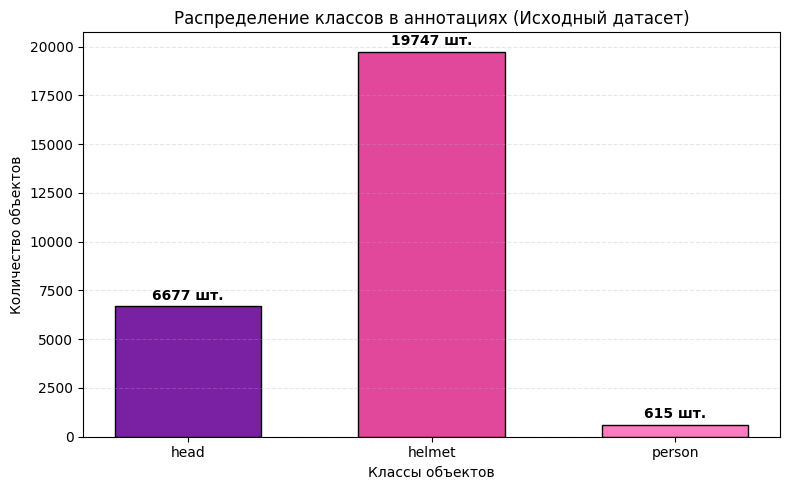

In [5]:
#Счёт аннотаций

import os
from collections import Counter
import matplotlib.pyplot as plt

DATASET_DIR = "extracted_dataset"

label_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for f in files:
        if f.endswith(".txt") and "labels" in root:
            label_files.append(os.path.join(root, f))

print(f"Найдено файлов аннотаций: {len(label_files)}")

class_names = {0: "head", 1: "helmet", 2: "person"}
class_counter = Counter()

for file_path in label_files:
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                class_counter[cls_id] += 1

named_counter = {
    class_names.get(cid, str(cid)): cnt for cid, cnt in class_counter.items()
}

print("\n--- Результаты подсчёта объектов ---")
for name, cnt in sorted(named_counter.items()):
    print(f"{name}: {cnt} шт.")

classes = sorted(named_counter.keys())
counts = [named_counter[cls] for cls in classes]

plt.figure(figsize=(8, 5))
colors = ["#7A20A3", "#E1479B", "#FF7BBF"]
bars = plt.bar(classes, counts, color=colors, edgecolor="black", width=0.6)

plt.xlabel("Классы объектов")
plt.ylabel("Количество объектов")
plt.title("Распределение классов в аннотациях (Исходный датасет)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, cnt in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.01,
        f"{cnt} шт.",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()

In [7]:
#Удаление дубликатов по хешам

import hashlib
import os
import shutil
from tqdm import tqdm

ORIGINAL_DIR = "extracted_dataset"
BACKUP_DIR = "dataset_backup"
WORK_DIR = "dataset_clean"

if not os.path.exists(BACKUP_DIR):
    print(f"Создание резервной копии: {ORIGINAL_DIR} -> {BACKUP_DIR}")
    shutil.copytree(ORIGINAL_DIR, BACKUP_DIR)
    print("Резервная копия успешно создана.")
else:
    print(f"Резервная копия уже существует: {BACKUP_DIR}")

if not os.path.exists(WORK_DIR):
    print(f"Создание рабочей копии: {ORIGINAL_DIR} -> {WORK_DIR}")
    shutil.copytree(ORIGINAL_DIR, WORK_DIR)
    print("Рабочая копия успешно создана.")
else:
    print(f"Рабочая копия уже существует: {WORK_DIR}")


def find_images(directory, extensions=(".jpg", ".jpeg", ".png")):
    for root, dirs, files in os.walk(directory):
        for f in files:
            if f.lower().endswith(extensions):
                yield os.path.join(root, f)

hashes = {}
duplicates = []

print(f"\nСканирование рабочей папки: {WORK_DIR}")
for img_path in tqdm(list(find_images(WORK_DIR)), desc="Поиск дубликатов"):
    with open(img_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    if file_hash in hashes:
        duplicates.append(img_path)
    else:
        hashes[file_hash] = img_path

if not duplicates:
    print("\nДубликаты не найдены — набор данных чист.")
else:
    print(f"\nНайдено дубликатов изображений: {len(duplicates)}")
    print("Первые 10 обнаруженных дубликатов:")
    for dup in duplicates[:10]:
        print("  -", dup)
    print("\nФайлы не удалены. Для удаления запустите следующий шаг очистки.")

Резервная копия уже существует: dataset_backup
Рабочая копия уже существует: dataset_clean

Сканирование рабочей папки: dataset_clean


Поиск дубликатов: 100%|██████████| 7035/7035 [00:00<00:00, 9451.86it/s]


Дубликаты не найдены — набор данных чист.


In [9]:
#Повышение разрешения

import os
import cv2
import numpy as np
from tqdm import tqdm

WORK_DIR = "dataset_clean"
MIN_DIM = 512
LAPLACIAN_THRESHOLD = 50


def find_images(directory):
    for root, _, files in os.walk(directory):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                yield os.path.join(root, f)


def image_quality_check(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return False, "нечитаемое"
    h, w = img.shape[:2]
    reasons = []
    if h < MIN_DIM or w < MIN_DIM:
        reasons.append(f"маленькое ({w}x{h})")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    if laplacian_var < LAPLACIAN_THRESHOLD:
        reasons.append(f"размытое (lap={laplacian_var:.1f})")
    if reasons:
        return False, ", ".join(reasons)
    return True, ""


def upscale_image(img, min_size=MIN_DIM):
    h, w = img.shape[:2]
    if min(h, w) >= min_size:
        return img
    scale = min_size / min(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)
    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)


def sharpen_image(img):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)


def enhance_image(img, reason):
    if "маленькое" in reason:
        img = upscale_image(img)
    if "размытое" in reason:
        img = sharpen_image(img)
    return img


all_images = list(find_images(WORK_DIR))
stats = {"good": 0, "enhanced": 0, "errors": 0}

print(f"Найдено изображений в рабочей папке: {len(all_images)}")
print("Запуск процесса фильтрации и улучшения качества...")

for img_path in tqdm(all_images, desc="Обработка"):
    ok, reason = image_quality_check(img_path)

    if ok:
        stats["good"] += 1
    else:
        img = cv2.imread(img_path)
        if img is None:
            stats["errors"] += 1
            continue
        enhanced_img = enhance_image(img, reason)
        cv2.imwrite(img_path, enhanced_img)
        stats["enhanced"] += 1

print("\nОбработка выборки завершена!")
print(f"Изначально качественные изображения: {stats['good']} шт.")
print(f"Успешно восстановлено и улучшено: {stats['enhanced']} шт.")
print(f"Ошибки при чтении файлов: {stats['errors']} шт.")

Найдено изображений в рабочей папке: 7035
Запуск процесса фильтрации и улучшения качества...


Обработка: 100%|██████████| 7035/7035 [01:13<00:00, 96.16it/s]


Обработка выборки завершена!
Изначально качественные изображения: 59 шт.
Успешно восстановлено и улучшено: 6976 шт.
Ошибки при чтении файлов: 0 шт.


In [12]:
#Удаление класса person

import os
import shutil
from tqdm import tqdm

SRC_DIR = "dataset_clean"
DST_DIR = "dataset_no_person"
CLASS_TO_REMOVE = 2
REMOVE = True


def find_label_files(directory):
    for root, _, files in os.walk(directory):
        for f in files:
            if f.endswith(".txt") and "labels" in root:
                yield os.path.join(root, f)

all_labels = list(find_label_files(SRC_DIR))
stats = {"total": len(all_labels), "modified": 0, "empty": 0, "kept": 0}

for label_path in tqdm(all_labels, desc="Обработка аннотаций"):
    with open(label_path, "r") as f:
        lines = f.readlines()

    new_lines = [
        line
        for line in lines
        if line.strip() and int(line.split()[0]) != CLASS_TO_REMOVE
    ]

    rel_path = os.path.relpath(label_path, SRC_DIR)
    dest_label_path = os.path.join(DST_DIR, rel_path)

    img_rel_path = rel_path.replace("labels", "images").rsplit(".", 1)[0]
    src_img_base = os.path.join(SRC_DIR, img_rel_path)
    dest_img_base = os.path.join(DST_DIR, img_rel_path)

    if len(new_lines) == len(lines):
        stats["kept"] += 1
        if REMOVE:
            os.makedirs(os.path.dirname(dest_label_path), exist_ok=True)
            shutil.copy2(label_path, dest_label_path)
            for ext in [".jpg", ".jpeg", ".png"]:
                if os.path.exists(src_img_base + ext):
                    os.makedirs(os.path.dirname(dest_img_base), exist_ok=True)
                    shutil.copy2(src_img_base + ext, dest_img_base + ext)
                    break
        continue

    stats["modified"] += 1

    if len(new_lines) == 0:
        stats["empty"] += 1
        continue

    if REMOVE:
        os.makedirs(os.path.dirname(dest_label_path), exist_ok=True)
        with open(dest_label_path, "w") as f:
            f.writelines(new_lines)

        for ext in [".jpg", ".jpeg", ".png"]:
            if os.path.exists(src_img_base + ext):
                os.makedirs(os.path.dirname(dest_img_base), exist_ok=True)
                shutil.copy2(src_img_base + ext, dest_img_base + ext)
                break

if REMOVE:
    for root, dirs, files in os.walk(SRC_DIR):
        for f in files:
            if "data.yaml" in f or "notes.txt" in f:
                src_path = os.path.join(root, f)
                rel_path = os.path.relpath(src_path, SRC_DIR)
                dst_path = os.path.join(DST_DIR, rel_path)
                os.makedirs(os.path.dirname(dst_path), exist_ok=True)
                shutil.copy2(src_path, dst_path)
    print(f"Очищенный набор данных успешно сохранён в '{DST_DIR}'")

print("\nСтатистика фильтрации:")
print(f"   Всего файлов аннотаций обработано: {stats['total']}")
print(f"   Изменено (удален класс person): {stats['modified']}")
print(f"   Исключено кадров (остался только класс person): {stats['empty']}")
print(f"   Сохранено без изменений: {stats['kept']}")

Обработка аннотаций: 100%|██████████| 7035/7035 [00:07<00:00, 966.74it/s]


Очищенный набор данных успешно сохранён в 'dataset_no_person'

Статистика фильтрации:
   Всего файлов аннотаций обработано: 7035
   Изменено (удален класс person): 209
   Исключено кадров (остался только класс person): 0
   Сохранено без изменений: 6826


In [ ]:
import shutil
shutil.make_archive('dataset_no_person', 'zip', 'dataset_no_person')
print("✅ dataset_no_person.zip готов")

✅ dataset_no_person.zip готов


In [13]:
import os


def calculate_iou(box1, box2):
    b1_x1, b1_x2 = box1[0] - box1[2] / 2, box1[0] + box1[2] / 2
    b1_y1, b1_y2 = box1[1] - box1[3] / 2, box1[1] + box1[3] / 2
    b2_x1, b2_x2 = box2[0] - box2[2] / 2, box2[0] + box2[2] / 2
    b2_y1, b2_y2 = box2[1] - box2[3] / 2, box2[1] + box2[3] / 2

    inter_x1 = max(b1_x1, b2_x1)
    inter_y1 = max(b1_y1, b2_y1)
    inter_x2 = min(b1_x2, b2_x2)
    inter_y2 = min(b1_y2, b2_y2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    box1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    box2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0


DATASET_DIR = "dataset_no_person"
suspicious_files = []

for root, _, files in os.walk(DATASET_DIR):
    for f in files:
        if f.endswith(".txt") and "labels" in root:
            boxes = []
            with open(os.path.join(root, f), "r") as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        boxes.append([float(x) for x in parts[1:5]])

            for i in range(len(boxes)):
                for j in range(i + 1, len(boxes)):
                    if calculate_iou(boxes[i], boxes[j]) > 0.7:
                        suspicious_files.append(os.path.join(root, f))
                        break

print(f"Найдено файлов с подозрением на двойную разметку: {len(set(suspicious_files))}")
for f in list(set(suspicious_files))[:5]:
    print("  - Подозрительный файл:", f)

Найдено файлов с подозрением на двойную разметку: 5
  - Подозрительный файл: dataset_no_person/Глава 2. Исходный датасет/train/labels/002109_jpg.rf.7281fd4774d7f0ee2c992328b85e5c77.txt
  - Подозрительный файл: dataset_no_person/Глава 2. Исходный датасет/train/labels/001042_jpg.rf.0c4e67c659759bc82569a30b153e8da4.txt
  - Подозрительный файл: dataset_no_person/Глава 2. Исходный датасет/train/labels/003385_jpg.rf.854dba11d3cd214366e91e04756e4c99.txt
  - Подозрительный файл: dataset_no_person/Глава 2. Исходный датасет/train/labels/002433_jpg.rf.77e4459c9b7ee8a592a4740513af737d.txt
  - Подозрительный файл: dataset_no_person/Глава 2. Исходный датасет/train/labels/002686_jpg.rf.0073332be9723e276e147b7dacecb6ea.txt


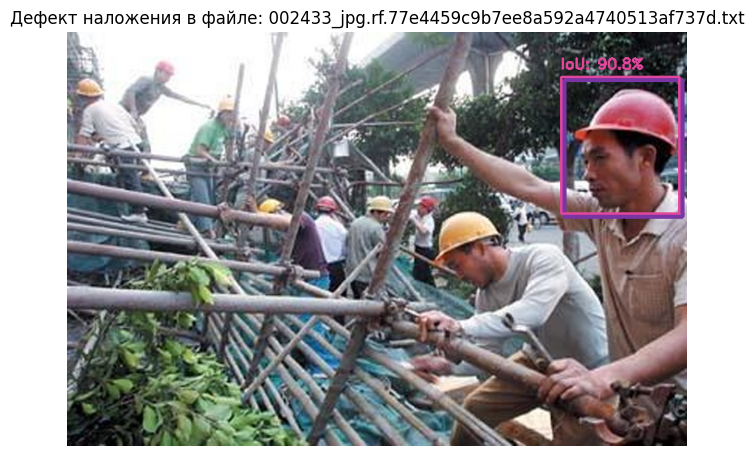

Файл markup_defect_0.png успешно сохранен.


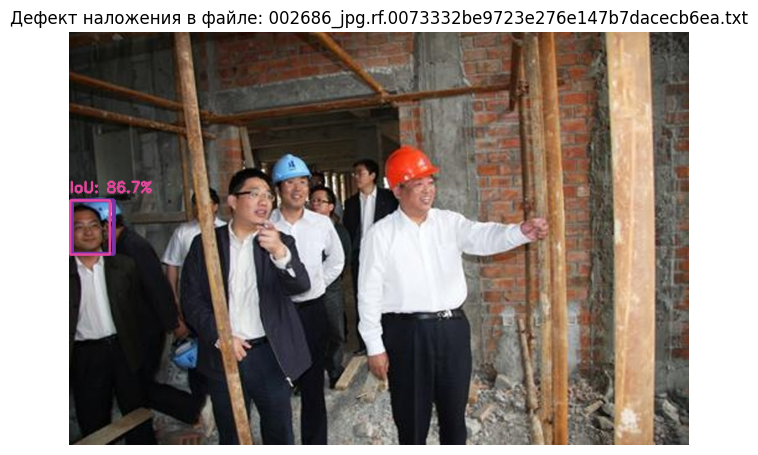

Файл markup_defect_1.png успешно сохранен.


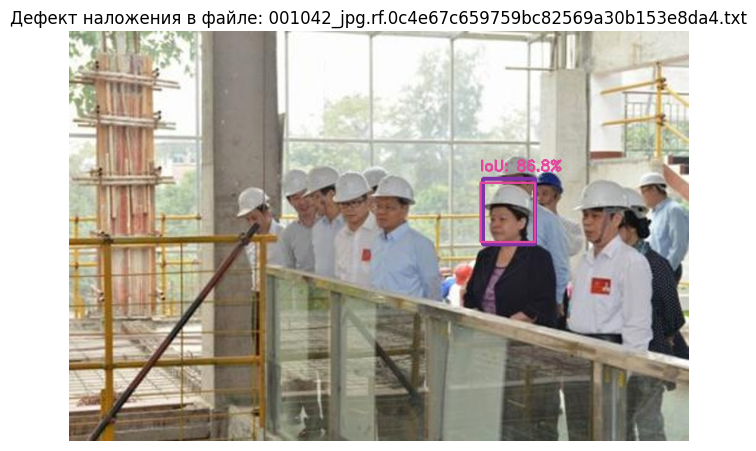

Файл markup_defect_2.png успешно сохранен.


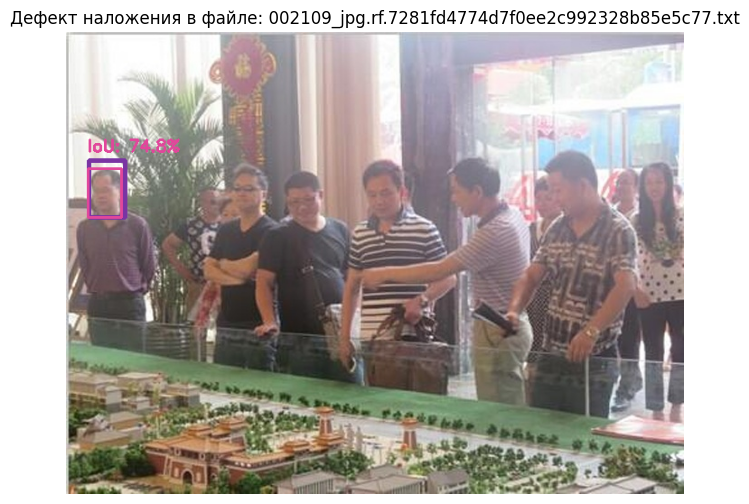

Файл markup_defect_3.png успешно сохранен.


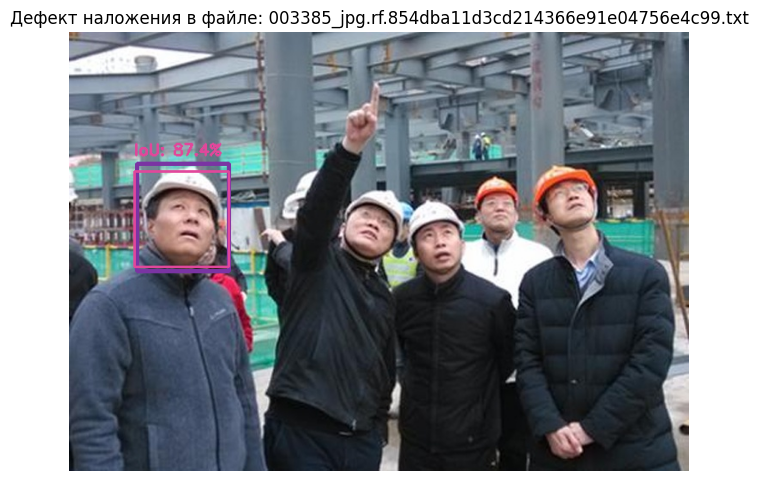

Файл markup_defect_4.png успешно сохранен.


In [16]:
#Наложение head и helmet

import os
import cv2
import matplotlib.pyplot as plt

def calculate_iou(box1, box2):
    b1_x1, b1_x2 = box1[0] - box1[2] / 2, box1[0] + box1[2] / 2
    b1_y1, b1_y2 = box1[1] - box1[3] / 2, box1[1] + box1[3] / 2
    b2_x1, b2_x2 = box2[0] - box2[2] / 2, box2[0] + box2[2] / 2
    b2_y1, b2_y2 = box2[1] - box2[3] / 2, box2[1] + box2[3] / 2

    inter_x1 = max(b1_x1, b2_x1)
    inter_y1 = max(b1_y1, b2_y1)
    inter_x2 = min(b1_x2, b2_x2)
    inter_y2 = min(b1_y2, b2_y2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    box1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    box2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0


DATASET_DIR = "dataset_no_person"
displayed_count = 0

for root, _, files in os.walk(DATASET_DIR):
    for f in files:
        if f.endswith(".txt") and "labels" in root:
            label_path = os.path.join(root, f)

            img_path_base = label_path.replace("labels", "images").rsplit(
                ".", 1
            )[0]
            img_path = None
            for ext in [".jpg", ".jpeg", ".png"]:
                if os.path.exists(img_path_base + ext):
                    img_path = img_path_base + ext
                    break

            if not img_path:
                continue

            boxes = []
            with open(label_path, "r") as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        boxes.append(
                            [int(parts[0])] + [float(x) for x in parts[1:5]]
                        )

            found_defect_in_file = False
            for i in range(len(boxes)):
                for j in range(i + 1, len(boxes)):
                    iou_val = calculate_iou(boxes[i][1:], boxes[j][1:])

                    if iou_val > 0.7 and displayed_count < 5:
                        img = cv2.imread(img_path)
                        h, w, _ = img.shape

                        b1 = boxes[i]
                        x1 = int((b1[1] - b1[3] / 2) * w)
                        y1 = int((b1[2] - b1[4] / 2) * h)
                        x2 = int((b1[1] + b1[3] / 2) * w)
                        y2 = int((b1[2] + b1[4] / 2) * h)
                        cv2.rectangle(img, (x1, y1), (x2, y2), (163, 52, 122), 3)

                        b2 = boxes[j]
                        x1_2 = int((b2[1] - b2[3] / 2) * w)
                        y1_2 = int((b2[2] - b2[4] / 2) * h)
                        x2_2 = int((b2[1] + b2[3] / 2) * w)
                        y2_2 = int((b2[2] + b2[4] / 2) * h)
                        cv2.rectangle(
                            img, (x1_2, y1_2), (x2_2, y2_2), (155, 71, 225), 2
                        )

                        text = f"IoU: {iou_val*100:.1f}%"
                        cv2.putText(
                            img,
                            text,
                            (min(x1, x1_2), max(15, min(y1, y1_2) - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.6,
                            (155, 71, 225),
                            2,
                        )

                        plt.figure(figsize=(8, 6))
                        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                        plt.title(
                            f"Дефект наложения в файле: {f}",
                            fontsize=12,
                        )
                        plt.axis("off")

                        save_name = f"markup_defect_{displayed_count}.png"
                        plt.savefig(save_name, dpi=300, bbox_inches="tight")
                        plt.show()

                        print(f"Файл {save_name} успешно сохранен.")
                        displayed_count += 1
                        found_defect_in_file = True
                        break
                if found_defect_in_file:
                    break